# Per-Image Camera Configuration Integration
This notebook now supports reading and using per-image, per-camera configuration parameters from `.txt` files in the `cameraconfig` directory for each frame. The BEV pipeline will use these parameters for more accurate perspective transforms and fusion.

In [137]:
!pip install -r ../requirements.txt
print("Included all Libraries...!")

Included all Libraries...!


In [138]:
import cv2
import numpy as np
import os
import json
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional

In [139]:
def load_camera_config(camera_config_path):
    config_file = camera_config_path / 'camera_config.json'
    if config_file.exists():
        with open(config_file, 'r') as f:
            camera_config = json.load(f)
            print(f"Loaded camera configuration from {config_file}")
    else:
        print("No camera config found, using default parameters")
        camera_config = {}
    return camera_config

In [140]:
def read_per_image_camera_config(config_dir, frame_id):
    """
    Reads the per-image camera config .txt file for a given frame_id from config_dir.
    Returns a dict: {camera_name: {'posi_x':..., 'posi_y':..., 'posi_z':..., 'rot_x':..., 'rot_y':..., 'rot_z':...}, ...}
    """
    import csv
    config_path = Path(config_dir) / f"{frame_id}.txt"
    camera_params = {}
    if not config_path.exists():
        print(f"No per-image config found for frame {frame_id} at {config_path}")
        return camera_params
    with open(config_path, 'r') as f:
        reader = csv.reader(f)
        header = None
        for row in reader:
            if not row or row[0].startswith('#') or row[0].strip() == '':
                continue
            if header is None:
                header = [h.strip() for h in row]
                continue
            if len(row) < len(header):
                continue
            cam_name = row[0].replace('Main Camera-', '').replace(' ', '').replace('Camera-', '').replace('Camera', '').lower()
            params = {header[i].strip(): float(row[i]) for i in range(1, len(header))}
            camera_params[cam_name] = params
    return camera_params

In [141]:
def get_camera_intrinsics(camera_name, camera_config, default_intrinsics):
    if camera_name in camera_config:
        return camera_config[camera_name].get('intrinsics', default_intrinsics)
    return default_intrinsics

In [142]:
def get_perspective_transform_points(camera_name, img_height, img_width, bev_width, bev_height):
    if camera_name == 'front':
        src_points = np.array([
            [img_width * 0.1, img_height * 0.9],
            [img_width * 0.9, img_height * 0.9],
            [img_width * 0.6, img_height * 0.4],
            [img_width * 0.4, img_height * 0.4]
        ], dtype=np.float32)
        dst_points = np.array([
            [bev_width * 0.3, bev_height * 0.8],
            [bev_width * 0.7, bev_height * 0.8],
            [bev_width * 0.7, bev_height * 0.2],
            [bev_width * 0.3, bev_height * 0.2]
        ], dtype=np.float32)
    elif camera_name == 'rear':
        src_points = np.array([
            [img_width * 0.1, img_height * 0.9],
            [img_width * 0.9, img_height * 0.9],
            [img_width * 0.6, img_height * 0.4],
            [img_width * 0.4, img_height * 0.4]
        ], dtype=np.float32)
        dst_points = np.array([
            [bev_width * 0.3, bev_height * 0.2],
            [bev_width * 0.7, bev_height * 0.2],
            [bev_width * 0.7, bev_height * 0.8],
            [bev_width * 0.3, bev_height * 0.8]
        ], dtype=np.float32)
    elif camera_name == 'left':
        src_points = np.array([
            [img_width * 0.1, img_height * 0.9],
            [img_width * 0.9, img_height * 0.9],
            [img_width * 0.6, img_height * 0.4],
            [img_width * 0.4, img_height * 0.4]
        ], dtype=np.float32)
        dst_points = np.array([
            [bev_width * 0.2, bev_height * 0.7],
            [bev_width * 0.8, bev_height * 0.7],
            [bev_width * 0.8, bev_height * 0.3],
            [bev_width * 0.2, bev_height * 0.3]
        ], dtype=np.float32)
    else:
        src_points = np.array([
            [img_width * 0.1, img_height * 0.9],
            [img_width * 0.9, img_height * 0.9],
            [img_width * 0.6, img_height * 0.4],
            [img_width * 0.4, img_height * 0.4]
        ], dtype=np.float32)
        dst_points = np.array([
            [bev_width * 0.2, bev_height * 0.3],
            [bev_width * 0.8, bev_height * 0.3],
            [bev_width * 0.8, bev_height * 0.7],
            [bev_width * 0.2, bev_height * 0.7]
        ], dtype=np.float32)
    return src_points, dst_points

In [143]:
def world_to_bev(world_x, world_y, bev_range_x, bev_range_y, meters_per_pixel):
    bev_x = int((world_x - bev_range_x[0]) / meters_per_pixel)
    bev_y = int((bev_range_y[1] - world_y) / meters_per_pixel)
    return bev_x, bev_y

In [144]:
def create_homography_matrix(camera_name, img_height, img_width, bev_width, bev_height):
    src_points, dst_points = get_perspective_transform_points(camera_name, img_height, img_width, bev_width, bev_height)
    homography = cv2.getPerspectiveTransform(src_points, dst_points)
    return homography

In [145]:
def convert_image_to_bev(image, camera_name, bev_width, bev_height, cam_params):
    img_height, img_width = image.shape[:2]
    H = create_homography_matrix_from_params(cam_params, img_width, img_height, bev_width, bev_height)
    bev_img = cv2.warpPerspective(
        image, H, 
        (bev_width, bev_height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )
    return bev_img

In [146]:
import numpy as np
import cv2

def create_roi_mask(camera_name, bev_width, bev_height):
    mask = np.zeros((bev_height, bev_width), dtype=np.uint8)
    if camera_name == 'front':
        # Compact front region
        points = np.array([
            [bev_width * 0.35, bev_height * 0.6],
            [bev_width * 0.65, bev_height * 0.6],
            [bev_width * 0.75, bev_height * 0.1],
            [bev_width * 0.25, bev_height * 0.1]
        ], dtype=np.int32)
    elif camera_name == 'rear':
        # Compact rear region
        points = np.array([
            [bev_width * 0.35, bev_height * 0.9],
            [bev_width * 0.65, bev_height * 0.9],
            [bev_width * 0.75, bev_height * 0.6],
            [bev_width * 0.25, bev_height * 0.6]
        ], dtype=np.int32)
    elif camera_name == 'left':
        # Compact left region
        points = np.array([
            [bev_width * 0.1, bev_height * 0.75],
            [bev_width * 0.4, bev_height * 0.65],
            [bev_width * 0.4, bev_height * 0.35],
            [bev_width * 0.1, bev_height * 0.25]
        ], dtype=np.int32)
    else:
        # Compact right region
        points = np.array([
            [bev_width * 0.9, bev_height * 0.75],
            [bev_width * 0.6, bev_height * 0.65],
            [bev_width * 0.6, bev_height * 0.35],
            [bev_width * 0.9, bev_height * 0.25]
        ], dtype=np.int32)
    cv2.fillPoly(mask, [points], 255)
    return mask

def get_perspective_transform_points(camera_name, img_height, img_width, bev_width, bev_height):
    # This function should return the source and destination points for the perspective transform
    # based on the camera name and image/BEV dimensions.
    # For now, we will return dummy points that should be replaced with actual logic.
    if camera_name == 'front':
        src_points = np.array([[0, 0], [img_width, 0], [img_width, img_height], [0, img_height]], dtype=np.float32)
        dst_points = np.array([[bev_width * 0.35, bev_height * 0.6], [bev_width * 0.65, bev_height * 0.6],
                               [bev_width * 0.75, bev_height * 0.1], [bev_width * 0.25, bev_height * 0.1]], dtype=np.float32)
    elif camera_name == 'rear':
        src_points = np.array([[0, 0], [img_width, 0], [img_width, img_height], [0, img_height]], dtype=np.float32)
        dst_points = np.array([[bev_width * 0.35, bev_height * 0.9], [bev_width * 0.65, bev_height * 0.9],
                               [bev_width * 0.75, bev_height * 0.6], [bev_width * 0.25, bev_height * 0.6]], dtype=np.float32)
    elif camera_name == 'left':
        src_points = np.array([[0, 0], [img_width, 0], [img_width, img_height], [0, img_height]], dtype=np.float32)
        dst_points = np.array([[bev_width * 0.1, bev_height * 0.75], [bev_width * 0.4, bev_height * 0.65],
                               [bev_width * 0.4, bev_height * 0.35], [bev_width * 0.1, bev_height * 0.25]], dtype=np.float32)
    else:
        src_points = np.array([[0, 0], [img_width, 0], [img_width, img_height], [0, img_height]], dtype=np.float32)
        dst_points = np.array([[bev_width * 0.9, bev_height * 0.75], [bev_width * 0.6, bev_height * 0.65],
                               [bev_width * 0.6, bev_height * 0.35], [bev_width * 0.9, bev_height * 0.25]], dtype=np.float32)

    return src_points, dst_points

def create_homography_matrix(camera_name, img_height, img_width, bev_width, bev_height, cam_params=None, default_intrinsics=None):
    # For now, still use get_perspective_transform_points, but can be extended to use cam_params
    src_points, dst_points = get_perspective_transform_points(camera_name, img_height, img_width, bev_width, bev_height)
    # Optionally, use cam_params for more accurate src_points/dst_points if available
    # (Extend here if your .txt files provide explicit points or calibration)
    homography = cv2.getPerspectiveTransform(src_points, dst_points)
    return homography

In [147]:
def fuse_bev_images(bev_images, bev_width, bev_height):
    # Use feathered masks for smooth blending
    order = ['rear', 'right', 'left', 'front']
    fused_bev = np.zeros((bev_height, bev_width, 3), dtype=np.float32)
    weight_sum = np.zeros((bev_height, bev_width, 1), dtype=np.float32)
    for camera_name in order:
        bev_img = bev_images.get(camera_name)
        if bev_img is not None:
            mask = create_feathered_roi_mask(camera_name, bev_width, bev_height)
            mask_3ch = np.repeat(mask[:, :, np.newaxis], 3, axis=2)
            fused_bev += bev_img.astype(np.float32) * mask_3ch
            weight_sum += mask[:, :, np.newaxis]
    # Avoid division by zero
    weight_sum[weight_sum == 0] = 1
    fused_bev = fused_bev / weight_sum
    fused_bev = np.clip(fused_bev, 0, 255).astype(np.uint8)
    return fused_bev

def convert_image_to_bev(image, camera_name, bev_width, bev_height, cam_params):
    img_height, img_width = image.shape[:2]
    H = create_homography_matrix_from_params(cam_params, img_width, img_height, bev_width, bev_height)
    bev_img = cv2.warpPerspective(
        image, H, 
        (bev_width, bev_height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )
    return bev_img

In [148]:
def process_frame(frame_id, rgb_path, bev_width, bev_height, per_image_config_dir, verbose=False):
    per_image_params = read_per_image_camera_config(per_image_config_dir, frame_id)
    bev_images = {}
    found_cameras = []
    for camera_name in ['front', 'rear', 'left', 'right']:
        possible_paths = [
            rgb_path / camera_name / f"{frame_id}.jpg",
            rgb_path / camera_name / f"{frame_id}.jpeg",
            rgb_path / camera_name / f"{frame_id}.png",
            rgb_path / camera_name / f"{frame_id}.JPG",
            rgb_path / camera_name / f"{frame_id}.JPEG",
            rgb_path / camera_name / f"{frame_id}.PNG"
        ]
        img_path = None
        for path in possible_paths:
            if path.exists():
                img_path = path
                break
        cam_key = camera_name.lower()
        if img_path and cam_key in per_image_params:
            img = cv2.imread(str(img_path))
            if img is not None:
                cam_params = per_image_params[cam_key]
                bev_img = convert_image_to_bev(img, camera_name, bev_width, bev_height, cam_params)
                bev_images[camera_name] = bev_img
                found_cameras.append(camera_name)
                if verbose:
                    print(f"✓ Processed {camera_name} camera")
            elif verbose:
                print(f"✗ Failed to load {camera_name} image")
        elif verbose:
            print(f"✗ {camera_name} image not found or no config")
    if verbose:
        print(f"Found cameras: {', '.join(found_cameras)}")
    if bev_images:
        fused_bev = fuse_bev_images(bev_images, bev_width, bev_height)
        return fused_bev
    else:
        if verbose:
            print(f"No valid images found for frame {frame_id}")
        return None

In [149]:
def process_dataset(output_dir, rgb_path, bev_width, bev_height, meters_per_pixel, bev_range_x, bev_range_y, camera_config, default_intrinsics, max_frames=None, verbose=False, per_image_config_dir=None):
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    frame_ids = []
    for camera_name in ['front', 'rear', 'left', 'right']:
        camera_dir = rgb_path / camera_name
        if camera_dir.exists():
            if verbose:
                print(f"Checking {camera_name} directory...")
            frame_files = []
            for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
                frame_files.extend(list(camera_dir.glob(ext)))
            if frame_files:
                frame_ids = [f.stem for f in frame_files]
                print(f"Found {len(frame_ids)} frames in {camera_name} directory")
                break
    if not frame_ids:
        print("❌ No frames found in any camera directory")
        return
    if max_frames:
        frame_ids = frame_ids[:max_frames]
    print(f"🚀 Processing {len(frame_ids)} frames...")
    success_count = 0
    for i, frame_id in enumerate(frame_ids):
        if verbose or (i + 1) % 10 == 0:
            print(f"Processing frame {i+1}/{len(frame_ids)}: {frame_id}")
        bev_result = process_frame(frame_id, rgb_path, bev_width, bev_height, per_image_config_dir=per_image_config_dir, verbose=verbose)
        if bev_result is not None:
            output_file = output_path / f"bev_{frame_id}.jpg"
            success = cv2.imwrite(str(output_file), bev_result)
            if success:
                success_count += 1
                if verbose:
                    print(f"✅ Saved: {output_file}")
            else:
                print(f"❌ Failed to save: {output_file}")
        if (i + 1) % 10 == 0:
            print(f"Progress: {i+1}/{len(frame_ids)} ({success_count} successful)")
    print(f"🎉 Completed! {success_count}/{len(frame_ids)} frames processed successfully")

In [150]:
def visualize_frame(frame_id, rgb_path, bev_width, bev_height, meters_per_pixel, bev_range_x, bev_range_y, camera_config, default_intrinsics, save_path=None, per_image_config_dir=None):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'BEV Conversion - Frame {frame_id}', fontsize=16)
    cameras = ['front', 'left', 'right', 'rear']
    positions = [(0, 1), (1, 0), (1, 2), (1, 1)]
    for camera, pos in zip(cameras, positions):
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            test_path = rgb_path / camera / f"{frame_id}{ext}"
            if test_path.exists():
                img_path = test_path
                break
        if img_path and img_path.exists():
            img = cv2.imread(str(img_path))
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[pos].imshow(img_rgb)
                axes[pos].set_title(f'{camera.capitalize()} Camera')
                axes[pos].axis('off')
            else:
                axes[pos].text(0.5, 0.5, f'{camera.capitalize()}\nFailed to load', 
                             ha='center', va='center', transform=axes[pos].transAxes)
                axes[pos].axis('off')
        else:
            axes[pos].text(0.5, 0.5, f'{camera.capitalize()}\nNot found', 
                         ha='center', va='center', transform=axes[pos].transAxes)
            axes[pos].axis('off')
    bev_result = process_frame(frame_id, rgb_path, bev_width, bev_height, per_image_config_dir, verbose=True)
    if bev_result is not None:
        bev_rgb = cv2.cvtColor(bev_result, cv2.COLOR_BGR2RGB)
        axes[0, 0].imshow(bev_rgb)
        axes[0, 0].set_title('Fused BEV')
        axes[0, 0].axis('off')
    else:
        axes[0, 0].text(0.5, 0.5, 'BEV\nGeneration Failed', 
                      ha='center', va='center', transform=axes[0, 0].transAxes)
        axes[0, 0].axis('off')
    axes[0, 2].axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Visualization saved: {save_path}")
    plt.show()

def process_frame(frame_id, rgb_path, bev_width, bev_height, per_image_config_dir=None, verbose=False):
    # Read per-image config if available
    per_image_params = {}
    if per_image_config_dir is not None:
        per_image_params = read_per_image_camera_config(per_image_config_dir, frame_id)
    bev_images = {}
    found_cameras = []
    for camera_name in ['front', 'rear', 'left', 'right']:
        possible_paths = [
            rgb_path / camera_name / f"{frame_id}.jpg",
            rgb_path / camera_name / f"{frame_id}.jpeg",
            rgb_path / camera_name / f"{frame_id}.png",
            rgb_path / camera_name / f"{frame_id}.JPG",
            rgb_path / camera_name / f"{frame_id}.JPEG",
            rgb_path / camera_name / f"{frame_id}.PNG"
        ]
        img_path = None
        for path in possible_paths:
            if path.exists():
                img_path = path
                break
        if img_path and camera_name in per_image_params:
            img = cv2.imread(str(img_path))
            if img is not None:
                cam_params = per_image_params[camera_name]
                bev_img = convert_image_to_bev(img, camera_name, bev_width, bev_height, cam_params)
                bev_images[camera_name] = bev_img
                found_cameras.append(camera_name)
                if verbose:
                    print(f"✓ Processed {camera_name} camera")
            elif verbose:
                print(f"✗ Failed to load {camera_name} image")
        elif verbose:
            print(f"✗ {camera_name} image not found")
    if verbose:
        print(f"Found cameras: {', '.join(found_cameras)}")
    if bev_images:
        fused_bev = fuse_bev_images(bev_images, bev_width, bev_height)
        return fused_bev
    else:
        if verbose:
            print(f"No valid images found for frame {frame_id}")
        return None

In [151]:
from pathlib import Path
import cv2

def check_directory_structure(dataset_path):
    base_path = Path(dataset_path)
    print(f"📁 Checking directory structure at: {base_path}")
    print(f"Base path exists: {base_path.exists()}")
    if base_path.exists():
        print("\n📂 Directory contents:")
        dirs_found = []
        images_found = 0
        for item in base_path.rglob("*"):
            if item.is_dir():
                dirs_found.append(str(item.relative_to(base_path)))
            elif item.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                images_found += 1
        for dir_path in sorted(dirs_found)[:20]:
            print(f"  📁 {dir_path}")
        if len(dirs_found) > 20:
            print(f"  ... and {len(dirs_found) - 20} more directories")
        print(f"\n📸 Total images found: {images_found}")
    else:
        print("❌ Path does not exist!")

def process_dataset(output_dir, rgb_path, bev_width, bev_height, meters_per_pixel, bev_range_x, bev_range_y, camera_config, default_intrinsics, max_frames=None, verbose=False, per_image_config_dir=None):
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    frame_ids = []
    for camera_name in ['front', 'rear', 'left', 'right']:
        camera_dir = rgb_path / camera_name
        if camera_dir.exists():
            if verbose:
                print(f"Checking {camera_name} directory...")
            frame_files = []
            for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
                frame_files.extend(list(camera_dir.glob(ext)))
            if frame_files:
                frame_ids = [f.stem for f in frame_files]
                print(f"Found {len(frame_ids)} frames in {camera_name} directory")
                break
    if not frame_ids:
        print("❌ No frames found in any camera directory")
        return
    if max_frames:
        frame_ids = frame_ids[:max_frames]
    print(f"🚀 Processing {len(frame_ids)} frames...")
    success_count = 0
    for i, frame_id in enumerate(frame_ids):
        if verbose or (i + 1) % 10 == 0:
            print(f"Processing frame {i+1}/{len(frame_ids)}: {frame_id}")
        bev_result = process_frame(frame_id, rgb_path, bev_width, bev_height, per_image_config_dir=per_image_config_dir, verbose=verbose)
        if bev_result is not None:
            output_file = output_path / f"bev_{frame_id}.jpg"
            success = cv2.imwrite(str(output_file), bev_result)
            if success:
                success_count += 1
                if verbose:
                    print(f"✅ Saved: {output_file}")
            else:
                print(f"❌ Failed to save: {output_file}")
        if (i + 1) % 10 == 0:
            print(f"Progress: {i+1}/{len(frame_ids)} ({success_count} successful)")
    print(f"🎉 Completed! {success_count}/{len(frame_ids)} frames processed successfully")

In [152]:
def main():
    dataset_path = r"D:\Mtech\Disseration\BEV_Adas\Dataset\images0"
    check_directory_structure(dataset_path)
    rgb_path = Path(dataset_path) / 'train' / 'rgb'
    camera_config_path = Path(dataset_path) / 'train' / 'cameraconfig'
    per_image_config_dir = camera_config_path  # Directory with per-image .txt files
    camera_config = load_camera_config(camera_config_path)
    default_intrinsics = {
        'fx': 800, 'fy': 800,
        'cx': 640, 'cy': 360,
        'k1': 0, 'k2': 0, 'k3': 0,
        'p1': 0, 'p2': 0
    }
    bev_width = 800
    bev_height = 800
    meters_per_pixel = 0.1
    bev_range_x = (-20, 20)
    bev_range_y = (-20, 20)
    possible_paths = [
        rgb_path / 'front',
        Path(dataset_path) / 'rgb' / 'front',
        Path(dataset_path) / 'front',
        Path(dataset_path) / 'train' / 'front'
    ]
    front_dir = None
    for path in possible_paths:
        print(f"Checking path: {path}")
        if path.exists():
            front_dir = path
            print(f"Found front directory at: {front_dir}")
            break
    if front_dir:
        frame_files = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
            frame_files.extend(list(front_dir.glob(ext)))
        print(f"Found {len(frame_files)} image files")
        if frame_files:
            test_frame_id = frame_files[0].stem
            print(f"Testing with frame: {test_frame_id}")
            if front_dir != rgb_path / 'front':
                rgb_path = front_dir.parent
                print(f"Updated RGB path to: {rgb_path}")
            print(f"\n🎨 Creating visualization for frame: {test_frame_id}")
            visualize_frame(test_frame_id, rgb_path, bev_width, bev_height, meters_per_pixel, bev_range_x, bev_range_y, camera_config, default_intrinsics, f"bev_visualization_{test_frame_id}.png", per_image_config_dir=per_image_config_dir)
            print(f"\n🔄 Processing batch of frames...")
            output_dir = "bev_output"
            process_dataset(output_dir, rgb_path, bev_width, bev_height, meters_per_pixel, bev_range_x, bev_range_y, camera_config, default_intrinsics, max_frames=5, verbose=False, per_image_config_dir=per_image_config_dir)
        else:
            print("No image files found in any front camera directory")
            print("Supported formats: JPG, JPEG, PNG")
    else:
        print("Front camera directory not found in any expected location")
        print("Expected locations:")
        for path in possible_paths:
            print(f"  - {path}")

📁 Checking directory structure at: D:\Mtech\Disseration\BEV_Adas\Dataset\images0
Base path exists: True

📂 Directory contents:
  📁 test
  📁 test\cameraconfig
  📁 test\depth
  📁 test\rgb
  📁 test\rgb\bev
  📁 test\rgb\front
  📁 test\rgb\left
  📁 test\rgb\rear
  📁 test\rgb\right
  📁 test\seg
  📁 test\seg\bev
  📁 test\seg\front
  📁 test\seg\left
  📁 test\seg\rear
  📁 test\seg\right
  📁 train
  📁 train\cameraconfig
  📁 train\depth
  📁 train\rgb
  📁 train\rgb\bev
  ... and 25 more directories

📸 Total images found: 11000
No camera config found, using default parameters
Checking path: D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\rgb\front
Found front directory at: D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\rgb\front
Found 1402 image files
Testing with frame: 0

🎨 Creating visualization for frame: 0
✓ Processed front camera
✓ Processed rear camera
✓ Processed left camera
✓ Processed right camera
Found cameras: front, rear, left, right
  📁 test
  📁 test\cameraconfig
  📁 test\dep

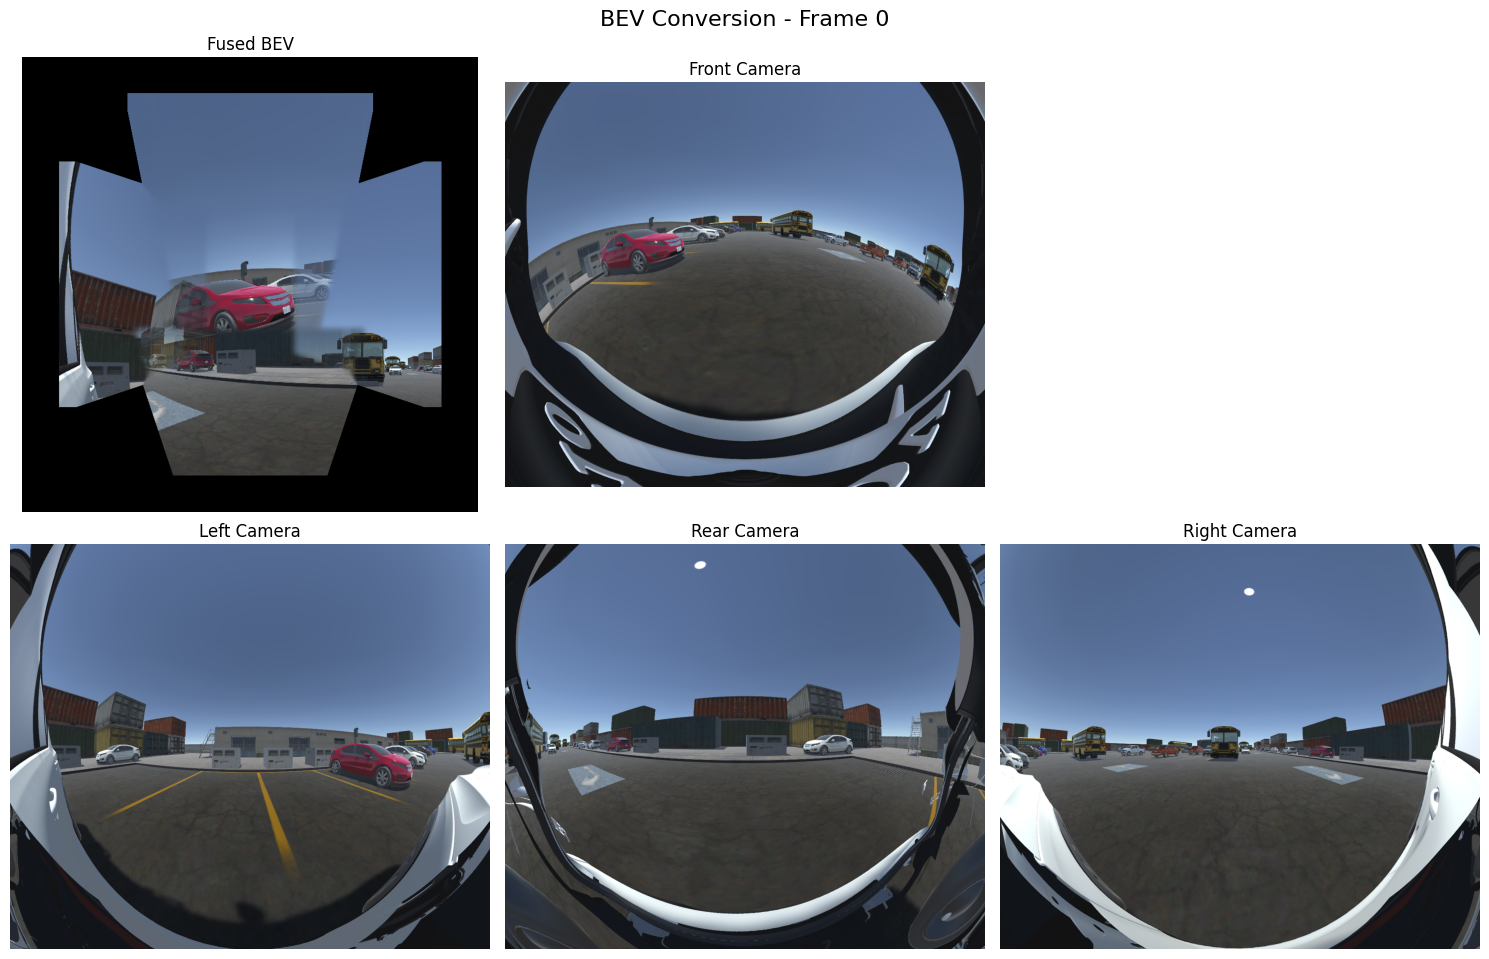


🔄 Processing batch of frames...
Found 1402 frames in front directory
🚀 Processing 5 frames...
🎉 Completed! 5/5 frames processed successfully
🎉 Completed! 5/5 frames processed successfully


In [155]:
if __name__ == "__main__":
    main()

In [154]:
def create_homography_matrix_from_params(params, img_width, img_height, bev_width, bev_height):
    """
    Create a homography matrix using camera extrinsic parameters.
    params: dict with keys posi_x, posi_y, posi_z, rot_x, rot_y, rot_z
    This is a placeholder. Replace with your actual math for projection.
    """
    # TODO: Implement actual homography using params
    return np.eye(3)